In [1]:
import os
import random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

In [2]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [3]:
MNIST_trn = torchvision.datasets.MNIST(os.path.join('MNIST_data'), download=True, train=True)
MNIST_tst = torchvision.datasets.MNIST(os.path.join('MNIST_data'), download=True, train=False)

In [4]:
X_trn = MNIST_trn.data
y_trn = MNIST_trn.targets

In [5]:
X_tst = MNIST_tst.data
y_tst = MNIST_tst.targets

In [6]:
X_trn.min(), X_trn.max()

(tensor(0, dtype=torch.uint8), tensor(255, dtype=torch.uint8))

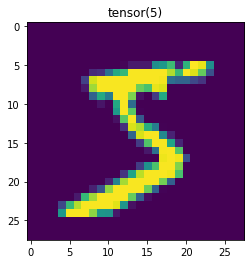

In [7]:
plt.imshow(X_trn[0])
plt.title(str(y_trn[0]));

In [8]:
X_trn[0].shape, 28*28

(torch.Size([28, 28]), 784)

In [9]:
X_trn = X_trn.unsqueeze(1).float()
X_tst = X_tst.unsqueeze(1).float()

In [10]:
X_trn.shape

torch.Size([60000, 1, 28, 28])

In [11]:
class MNISTNet(torch.nn.Module):
    
    def __init__(self):
        super(MNISTNet, self).__init__()
        
        self.conv1_1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, padding=1)
        self.conv1_2 = torch.nn.Conv2d(in_channels=6, out_channels=6, kernel_size=3, padding=1)
        self.maxpool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn1 = torch.nn.BatchNorm2d(num_features=6)
        self.act1 = torch.nn.ReLU()

        self.conv2_1 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, padding=0)
        self.conv2_2 = torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=0)
        self.maxpool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn2 = torch.nn.BatchNorm2d(16)
        self.act2 = torch.nn.ReLU()

        self.fc1 = torch.nn.Linear(5*5*16, 120)
        self.bn3 = torch.nn.BatchNorm1d(120)
        self.act4 = torch.nn.ReLU()
        
        self.fc2 = torch.nn.Linear(120, 84)
        self.bn4 = torch.nn.BatchNorm1d(84)
        self.act5 = torch.nn.ReLU()
        
        self.fc3 = torch.nn.Linear(84, 10)


    def forward(self, x):
        x = self.conv1_2(self.conv1_1(x))
        x = self.act1(x)
        x = self.bn1(x)
        x = self.maxpool1(x)

        x = self.conv2_2(self.conv2_1(x))
        x = self.act2(x)
        x = self.bn2(x)
        x = self.maxpool2(x)

        x = x.view(x.size(0), x.size(1)*x.size(2)*x.size(3))
        x = self.fc1(x)
        x = self.bn3(x)
        x = self.act4(x)
        
        x = self.fc2(x)
        x = self.act5(x)
        x = self.bn4(x)
        
        x = self.fc3(x)
        
        return x

In [12]:
def train(model,
          X_trn, y_trn,
          X_val, y_val,
          loss, optimizer, lr_scheduler,
          batch_size=100,
          epochs=30):
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    loss = loss
    optimizer = optimizer
    lr_scheduler = lr_scheduler
    
    val_acc_hist = []
    val_loss_hist = []
    
    X_val = X_val.to(device)
    y_val = y_val.to(device)
    
    for epoch in range(epochs):
        order = np.random.permutation(len(X_trn))
        for start_idx in range(0, len(X_trn), batch_size):
            optimizer.zero_grad()
            model.train()
            
            batch_idx = order[start_idx:start_idx + batch_size]
            
            X_batch = X_trn[batch_idx].to(device)
            y_batch = y_trn[batch_idx].to(device)
            
            preds = model.forward(X_batch)
            
            loss_value = loss(preds, y_batch)
            loss_value.backward()
            
            optimizer.step()
            
        model.eval()
        val_preds = model.forward(X_val)
        val_loss_hist.append(loss(val_preds, y_val).data.cpu())
        accuracy = (val_preds.argmax(dim=1) == y_val).float().mean().data.cpu()
        val_acc_hist.append(accuracy)
        
        print(f'epoch {epoch}: {accuracy:.6f}')
    print('-----------------------------------')
    
    return val_acc_hist, val_loss_hist

In [13]:
model = MNISTNet()
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,
                                                          factor=0.01,
                                                          patience=7)

In [14]:
model_acc, model_loss = train(model,
                              X_trn, y_trn,
                              X_tst, y_tst,
                              loss, optimizer,lr_scheduler,
                              batch_size=200, epochs=30)

epoch 0: 0.984500
epoch 1: 0.986100
epoch 2: 0.989800
epoch 3: 0.988400
epoch 4: 0.990700
epoch 5: 0.988900
epoch 6: 0.989000
epoch 7: 0.989700
epoch 8: 0.988300
epoch 9: 0.989500
epoch 10: 0.990000
epoch 11: 0.989200
epoch 12: 0.991300
epoch 13: 0.988000
epoch 14: 0.991100
epoch 15: 0.990200
epoch 16: 0.991500
epoch 17: 0.990000
epoch 18: 0.990700
epoch 19: 0.989400
epoch 20: 0.990700
epoch 21: 0.991400
epoch 22: 0.991100
epoch 23: 0.992100
epoch 24: 0.991900
epoch 25: 0.988800
epoch 26: 0.989500
epoch 27: 0.992300
epoch 28: 0.993200
epoch 29: 0.990600
-----------------------------------
